### Setup and Data Download

The following blocks of code will install the required packages and download the datasets to your Colab environment.

In [ ]:
%%capture
if 'google.colab' in str(get_ipython()):
    !pip install rioxarray dask['distributed'] \
    jupyter-server-proxy netCDF4

In [ ]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import os
import rioxarray as rxr
import xarray as xr


In [ ]:
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

If you are running this notebook in Colab, you will need to create and use a proxy URL to see the dashboard running on the local server.

In [ ]:
if 'google.colab' in str(get_ipython()):
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))


In [ ]:
data_folder = 'data'
output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

### Access TerraClimate Data

[TerraClimate](https://www.climatologylab.org/terraclimate.html) is long-term climatology dasaset that provides monthly-aggregated gridded data from 1950-present. It is hosted on a THREDDS Data Server (TDS) and served using the OPeNDAP (Open Data Access Protocol) protocol. XArray has built-in support to efficiently read and process OPeNDAP data where we can stream and process only the required pixels without downloading entire dataset.

In [ ]:
terraclimate_url = 'http://thredds.northwestknowledge.net:8080/thredds/dodsC/'
variable = 'tmax'
filename = f'agg_terraclimate_{variable}_1950_CurrentYear_GLOBE.nc'
remote_file_path = os.path.join(terraclimate_url, filename)
ds = xr.open_dataset(
    remote_file_path,
    chunks='auto',
    engine='netcdf4',
)
ds

### Extract a Time-Series

We define a location and time of interest to get the data

In [ ]:
latitude = 12.965
longitude = 77.577
start_year = 1970
end_year = 2025

In [ ]:
# Select the variable
da = ds.tmax

In [ ]:
# Select the time-period
da_filtered = da.sel(time=slice(f'{start_year}', f'{end_year}'))
da_filtered

In [ ]:
# Extract the value at the given coordinates
time_series = da_filtered.interp(lat=latitude, lon=longitude)
time_series

In [ ]:
%%time
time_series = time_series.compute()

Plot the time-series.

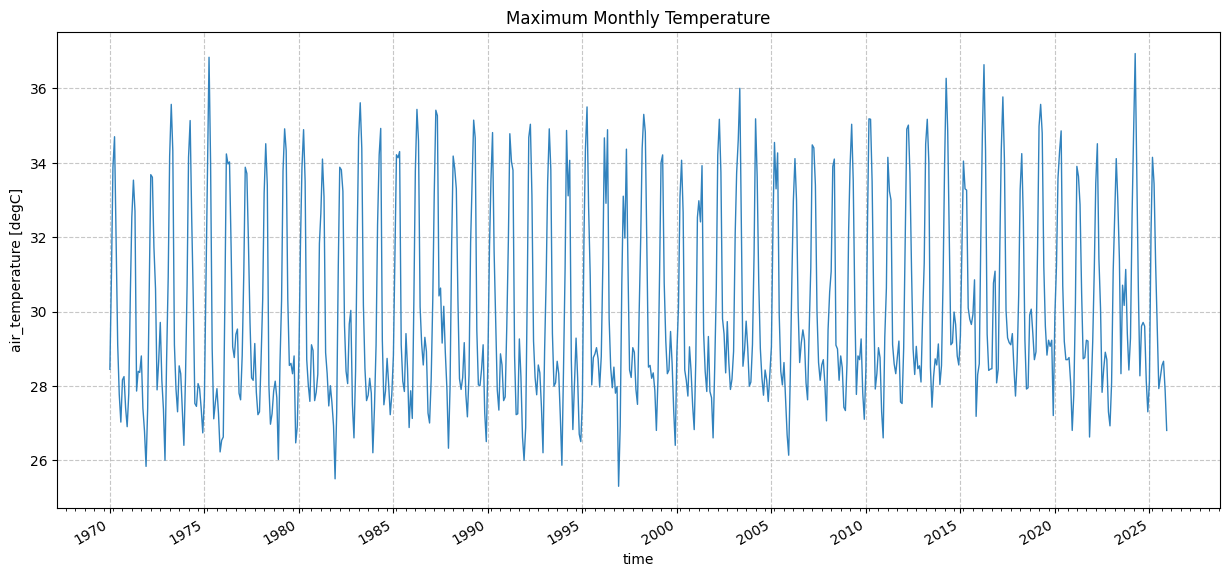

In [46]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(15, 7)

time_series.plot.line(
    ax=ax, x='time',
    marker='none', color='#3182bd',
    linestyle='-', linewidth=1, markersize=4)

# Format the x-axis to display dates more clearly
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(5)) # Major tick every 5 years
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=6)) # Minor tick every 6 months

ax.set_title('Maximum Monthly Temperature')
plt.grid(True, linestyle='--', alpha=0.7) # Add grid for readability
fig.autofmt_xdate() # Automatically format and rotate date labels
plt.show()